In [ ]:
!pip install ultralytics

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amiranmkrtchyan/amiran")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amiran' dataset.
Path to dataset files: /kaggle/input/amiran


In [ ]:
import pandas as pd
import numpy as np
from ultralytics import YOLO
import torch

import shutil
import os

import random


from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
import os
import shutil

dataset_base_path = "/kaggle/input/amiran/all_fields_lincolnbeet"

source_folder = os.path.join(dataset_base_path, "all")
train_list_file = os.path.join(dataset_base_path, "all_fields_lincolnbeet_train_.txt")
val_list_file = os.path.join(dataset_base_path, "all_fields_lincolnbeet_val_.txt")
test_list_file = os.path.join(dataset_base_path, "all_fields_lincolnbeet_test_.txt")


train_destination = "/kaggle/working/train"
valid_destination = "/kaggle/working/valid"
test_destination = "/kaggle/working/test"

# ایجاد پوشه‌های مقصد، اگر وجود ندارند
os.makedirs(os.path.join(train_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(train_destination, 'labels'), exist_ok=True)
os.makedirs(os.path.join(valid_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(valid_destination, 'labels'), exist_ok=True)
os.makedirs(os.path.join(test_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(test_destination, 'labels'), exist_ok=True)

def move_files(file_list_path, source_folder, destination_folder):
    with open(file_list_path, "r") as file:
        file_names = [os.path.basename(line.strip()) for line in file.readlines()]

    images_folder = os.path.join(destination_folder, "images")
    labels_folder = os.path.join(destination_folder, "labels")

    for file_name in file_names:
        image_file = os.path.join(source_folder, file_name)
        label_file = os.path.join(source_folder, file_name.replace(".png", ".txt"))
        if os.path.isfile(image_file):
            shutil.copy(image_file, images_folder)
        if os.path.isfile(label_file):
            shutil.copy(label_file, labels_folder)

move_files(train_list_file, source_folder, train_destination)
move_files(val_list_file, source_folder, valid_destination)
move_files(test_list_file, source_folder, test_destination)

print("فایل‌های دیتاست با موفقیت مرتب و در پوشه‌های مربوطه قرار گرفتند.")

فایل‌های دیتاست با موفقیت مرتب و در پوشه‌های مربوطه قرار گرفتند.


In [ ]:
def move_files(file_path, source_folder, destination_folder):

    with open(file_path, "r") as file:
        file_names = [os.path.basename(line.strip()) for line in file.readlines()]


    images_folder = os.path.join(destination_folder, "images")
    labels_folder = os.path.join(destination_folder, "labels")

    for file_name in file_names:
        image_file = os.path.join(source_folder, file_name)
        label_file = os.path.join(source_folder, file_name.replace(".png", ".txt"))
        if os.path.isfile(image_file):
            shutil.copy(image_file, images_folder)
        if os.path.isfile(label_file):
            shutil.copy(label_file, labels_folder)

In [ ]:
import os
import shutil

train_file = "/kaggle/input/amiran/all_fields_lincolnbeet/all_fields_lincolnbeet_train_.txt"
valid_file = "/kaggle/input/amiran/all_fields_lincolnbeet/all_fields_lincolnbeet_val_.txt"
test_file = "/kaggle/input/amiran/all_fields_lincolnbeet/all_fields_lincolnbeet_test_.txt"

source_folder = "/kaggle/input/amiran/all_fields_lincolnbeet/all"


train_destination = "/kaggle/working/train"
valid_destination = "/kaggle/working/valid"
test_destination = "/kaggle/working/test"

os.makedirs(os.path.join(train_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(train_destination, 'labels'), exist_ok=True)
os.makedirs(os.path.join(valid_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(valid_destination, 'labels'), exist_ok=True)
os.makedirs(os.path.join(test_destination, 'images'), exist_ok=True)
os.makedirs(os.path.join(test_destination, 'labels'), exist_ok=True)

def move_files(file_list_path, source_folder, destination_folder):

    with open(file_list_path, "r") as file:
        file_names = [os.path.basename(line.strip()) for line in file.readlines()]

    images_folder = os.path.join(destination_folder, "images")
    labels_folder = os.path.join(destination_folder, "labels")

    for file_name in file_names:
        image_file = os.path.join(source_folder, file_name)
        label_file = os.path.join(source_folder, file_name.replace(".png", ".txt"))
        if os.path.isfile(image_file):
            shutil.copy(image_file, images_folder)
        if os.path.isfile(label_file):
            shutil.copy(label_file, labels_folder)

move_files(train_file, source_folder, train_destination)
move_files(valid_file, source_folder, valid_destination)
move_files(test_file, source_folder, test_destination)

print("فایل‌های دیتاست با موفقیت مرتب و در پوشه‌های مربوطه قرار گرفتند.")

فایل‌های دیتاست با موفقیت مرتب و در پوشه‌های مربوطه قرار گرفتند.


In [ ]:
import  yaml

dataset = {
'train': '/kaggle/working/train',
'val': '/kaggle/working/valid',
'test': '/kaggle/working/test',
'nc': 2,
'names': ['crop', 'weed']
}

with open('/kaggle/working/dataset.yaml', 'w') as file:
    yaml.dump(dataset, file)

In [ ]:
ls /kaggle/working

dataset.yaml  test/  train/  valid/


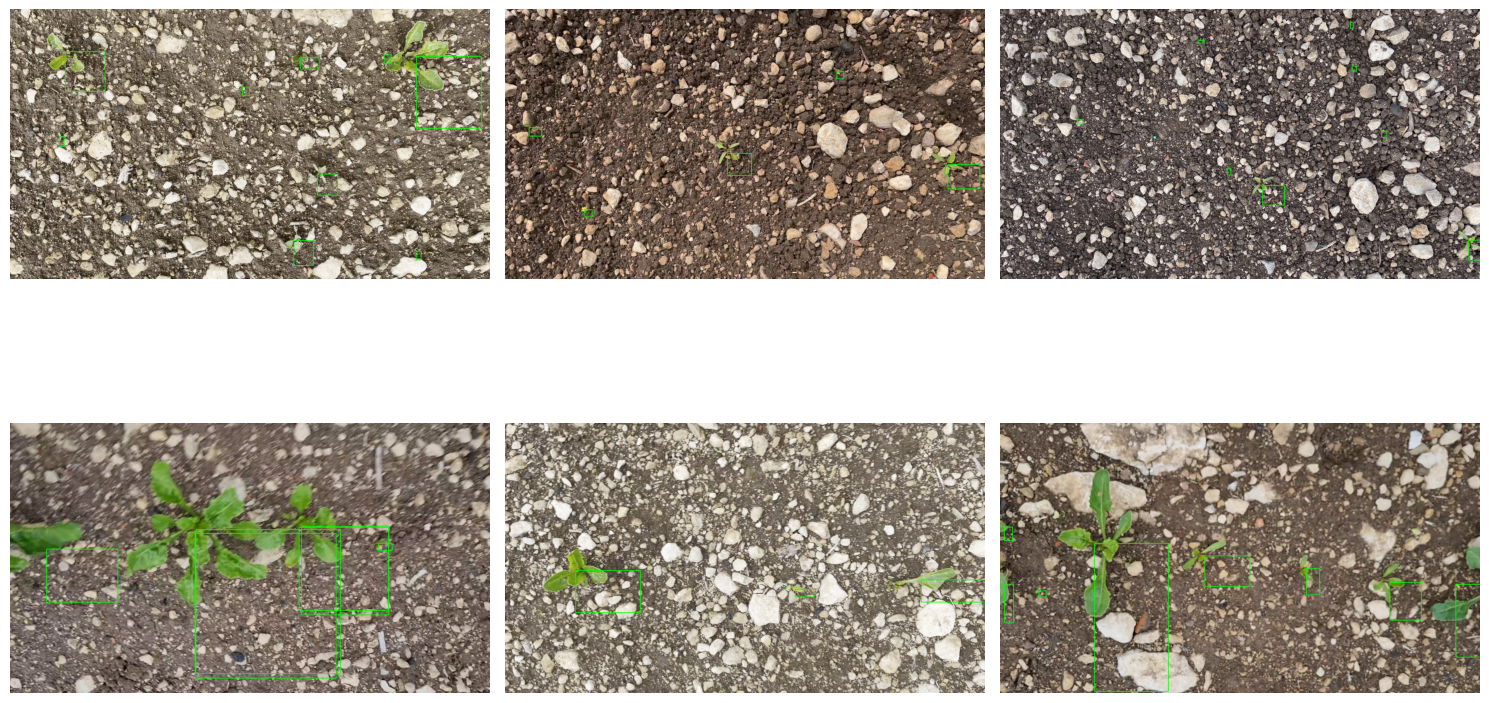

In [ ]:
images_folder = "/kaggle/working/train/images"
labels_folder = "/kaggle/working/train/labels"

image_files = os.listdir(images_folder)

random.shuffle(image_files)
random_image_files = image_files[:6]

num_images = len(random_image_files)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i in range(num_images):
    image_file = os.path.join(images_folder, random_image_files[i])
    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_file = os.path.join(labels_folder, os.path.splitext(random_image_files[i])[0] + ".txt")
    with open(label_file, "r") as file:
        labels = file.readlines()

    for label in labels:
        class_id, x, y, width, height = map(float, label.strip().split())
        x = int(x * image.shape[1])
        y = int(y * image.shape[0])
        width = int(width * image.shape[1])
        height = int(height * image.shape[0])
        cv2.rectangle(image, (x, y), (x + width, y + height), (0, 255, 0), 2)

    axes[i].imshow(image)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = YOLO('yolov8x.pt')

In [ ]:
model.train(data='/kaggle/working/dataset.yaml ', epochs=50, imgsz=640,
            optimizer = 'AdamW', lr0 = 1e-3,
            project = 'TG_YOLOv8x', name='Didi',
            batch=16, device=device, seed=69)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml , degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Didi, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12

In [ ]:
df = pd.read_csv('/kaggle/working/TG_YOLOv8x/Didi/results.csv')

In [ ]:
df.columns()

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.tight_layout()

# train/box_loss
axes[0, 0].plot(df['                  epoch'], df['         train/box_loss'], label='         train/box_loss')
axes[0, 0].set_title('Train Box Loss')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# val/box_loss
axes[0, 1].plot(df['                  epoch'], df['           val/box_loss'], label='           val/box_loss')
axes[0, 1].set_title('Validation Box Loss')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# train/cls_loss
axes[1, 0].plot(df['                  epoch'], df['         train/cls_loss'], label='         train/cls_loss')
axes[1, 0].set_title('Train Class Loss')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
# val/cls_loss
axes[1, 1].plot(df['                  epoch'], df['           val/cls_loss'], label='           val/cls_loss')
axes[1, 1].set_title('Validation Class Loss')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

# train/dfl_loss
axes[2, 0].plot(df['                  epoch'], df['         train/dfl_loss'], label='         train/dfl_loss')
axes[2, 0].set_title('Train Distribution Focal loss')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Loss')
axes[2, 0].legend()

# val/dfl_loss
axes[2, 1].plot(df['                  epoch'], df['           val/dfl_loss'], label='           val/dfl_loss')
axes[2, 1].set_title('Validation Distribution Focal loss')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('Loss')
axes[2, 1].legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.tight_layout()

# metrics/precision(B)
axes[0, 0].plot(df['                  epoch'], df['   metrics/precision(B)'], label='   metrics/precision(B)')
axes[0, 0].set_title('Precision')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].legend()

# metrics/recall(B)
axes[0, 1].plot(df['                  epoch'], df['      metrics/recall(B)'], label='      metrics/recall(B)')
axes[0, 1].set_title('Recall')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].legend()

# График для metrics/mAP50(B)
axes[1, 0].plot(df['                  epoch'], df['       metrics/mAP50(B)'], label='       metrics/mAP50(B)')
axes[1, 0].set_title('mAP@0.5')
axes[1, 0].set_ylabel('mAP@0.5')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()

# metrics/mAP50-95(B)
axes[1, 1].plot(df['                  epoch'], df['    metrics/mAP50-95(B)'], label='    metrics/mAP50-95(B)')
axes[1, 1].set_title('mAP@0.5:0.95')
axes[1, 1].set_ylabel('mAP@0.5:0.95')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()

plt.show()

In [ ]:
# F1_curve.png
f1_curve = Image.open("/kaggle/working/TG_YOLOv8x/Didi/F1_curve.png")
plt.figure(figsize=(10, 10))
plt.imshow(f1_curve)
plt.title("F1 Curve")
plt.axis("off")
plt.show()

# PR_curve.png
pr_curve = Image.open("/kaggle/working/TG_YOLOv8x/Didi/PR_curve.png")
plt.figure(figsize=(10, 10))
plt.imshow(pr_curve)
plt.title("Precision-Recall Curve")
plt.axis("off")
plt.show()

# P_curve.png
p_curve = Image.open("/kaggle/working/TG_YOLOv8x/Didi/P_curve.png")
plt.figure(figsize=(10, 10))
plt.imshow(p_curve)
plt.title("Precision Curve")
plt.axis("off")
plt.show()

# R_curve.png
r_curve = Image.open("/kaggle/working/TG_YOLOv8x/Didi/R_curve.png")
plt.figure(figsize=(10, 10))
plt.imshow(r_curve)
plt.title("Recall Curve")
plt.axis("off")
plt.show()

In [ ]:
# confusion matrix
confusion_matrix = Image.open("/kaggle/working/TG_YOLOv8x/Didi/confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix)
plt.title("Confusion Matrix")
plt.axis("off")
plt.show()

In [ ]:
res = model('/kaggle/working/test/images/bbro_bbro_14_05_2021_v_0_18.png')
detect_img = res[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(plt.imread('/kaggle/working/test/images/bbro_bbro_14_05_2021_v_0_18.png'))
axes[0].axis('off')

axes[1].imshow(detect_img)
axes[1].axis('off')

plt.show();

In [ ]:
model = YOLO('TG_YOLOv8x/Didi/weights/best.pt ')

In [ ]:
metrics = model.val(split='test', conf=0.25, device=device) # conf - это порог достоверности объекта для обнаружения

In [ ]:
metrics

In [ ]:
ax = sns.barplot(x=['mAP50-95', 'mAP50', 'mAP75'], y=[metrics.box.map, metrics.box.map50, metrics.box.map75])


ax.set_title('YOLO Evaluation Metrics')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')


fig = plt.gcf()
fig.set_size_inches(8, 6)

for p in ax.patches:
    ax.annotate('{:.3f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')


plt.show()

In [ ]:
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
f1 = (2 * precision * recall) / (precision + recall)


metrics = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]

ax = sns.barplot(x=metrics, y=values, palette='viridis')

ax.set_title('Precision, Recall, and F1 Scores')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')

for p in ax.patches:
    ax.annotate('{:.3f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.show()

In [ ]:
image_paths = random.sample(os.listdir(images_folder), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 12))
fig.tight_layout()

for i, ax in enumerate(axes.flat):
    image_path = os.path.join(images_folder, image_paths[i])
    image = Image.open(image_path)
    res = model(image, verbose=False)
    detect_img = res[0].plot()
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)

    ax.imshow(detect_img)
    ax.axis('off')

plt.show()